# Machine Learning Analysis and Forecasting of Electric Vehicle Adoption Trends

## Data Preprocessing

This notebook contains the data preparation, machine learning analysis, and forecasting workflow used to analyze electric vehicle adoption trends.

## 1. Import Libraries

In [121]:
import pandas as pd

## 2. Load the Dataset

In [122]:
url = "https://data.wa.gov/resource/f6w7-q2d2.csv"

df = pd.read_csv(url)

print(df.shape)

(1000, 16)


## 3. Inspect the Dataset

In [123]:
df.head()

,vin_1_10,county,city,state,zip_code,model_year,make,model,ev_type,cafv_type,electric_range,legislative_district,dol_vehicle_id,geocoded_column,electric_utility,_2020_census_tract
0,1N4AZ1CP3K,King,Shoreline,WA,98155.0,2019,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,150,32.0,168526641,POINT (-122.30304 47.75494),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303302e+10
1,WBY8P4C51K,King,Kirkland,WA,98033.0,2019,BMW,I3,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,126,48.0,9418181,POINT (-122.2066 47.67887),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
2,3FA6P0SU8G,Snohomish,Lynnwood,WA,98036.0,2016,FORD,FUSION,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,19,1.0,172853495,POINT (-122.29245 47.82557),PUGET SOUND ENERGY INC,5.306105e+10
3,5YJ3E1EB3N,Yakima,Wapato,WA,98951.0,2022,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,15.0,204768175,POINT (-120.42083 46.44779),PACIFICORP,5.307794e+10
4,WBY1Z2C53F,King,Renton,WA,98055.0,2015,BMW,I3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,81,11.0,269262920,POINT (-122.19488 47.44034),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10


## 4. Select Relevant Variables

The analysis focuses on model year, manufacturer, electric vehicle type, CAFV eligibility, electric range, and county.

In [124]:
df = df[[
    'model_year',
    'make',
    'ev_type',
    'cafv_type',
    'electric_range',
    'county'
]]

df.head()

,model_year,make,ev_type,cafv_type,electric_range,county
0,2019,NISSAN,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,150,King
1,2019,BMW,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,126,King
2,2016,FORD,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,19,Snohomish
3,2022,TESLA,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,Yakima
4,2015,BMW,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,81,King


## 5. Check Missing Values

In [125]:
df.isnull().sum()

,0
model_year,0
make,0
ev_type,0
cafv_type,0
electric_range,0
county,2


## 6. Handle Missing Values

Rows containing missing values are removed from the selected variables before further analysis.

In [126]:
df = df.dropna()

print(df.isnull().sum())
print(df.shape)

model_year        0
make              0
ev_type           0
cafv_type         0
electric_range    0
county            0
dtype: int64
(998, 6)


## 7. Check for Duplicate Records

In [127]:
df.duplicated().sum()

np.int64(412)

## 8. Remove Duplicate Records

Duplicate rows are removed to ensure that repeated records do not influence the subsequent analysis.

In [128]:
df = df.drop_duplicates()

print(df.shape)

(586, 6)


## 9. Encode Categorical Variables

Categorical variables are converted into numerical representations using `LabelEncoder` so they can be used by the machine learning models.

In [129]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['make'] = le.fit_transform(df['make'])
df['county'] = le.fit_transform(df['county'])
df['cafv_type'] = le.fit_transform(df['cafv_type'])
df['ev_type'] = le.fit_transform(df['ev_type'])

df.head()

,model_year,make,ev_type,cafv_type,electric_range,county
0,2019,22,0,0,150,9
1,2019,1,1,0,126,9
2,2016,7,1,2,19,15
3,2022,27,0,1,0,21
4,2015,1,0,0,81,9


## 10. Define Features and Target

The selected explanatory variables are used as features (`X`), while electric vehicle type is defined as the target variable (`y`).

In [130]:
X = df.drop('ev_type', axis=1)

y = df['ev_type']

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   model_year  make  cafv_type  electric_range  county
0        2019    22          0             150       9
1        2019     1          0             126       9
2        2016     7          2              19      15
3        2022    27          1               0      21
4        2015     1          0              81       9

Target:
0    0
1    1
2    1
3    0
4    0
Name: ev_type, dtype: int64


## 11. Split the Data into Training and Testing Sets

The dataset is divided into training and testing subsets. Eighty percent of the observations are used for model training, while the remaining twenty percent are reserved for evaluation.

In [131]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (468, 5)
Testing features: (118, 5)
Training target: (468,)
Testing target: (118,)


## 12. Random Forest Classification

In [132]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print(rf_pred[:10])

[0 0 1 0 0 0 1 0 0 1]


## 13. Evaluate Random Forest Performance

In [133]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 1.0


## 14. Random Forest Classification Report

In [134]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        75
           1       1.00      1.00      1.00        43

    accuracy                           1.00       118
   macro avg       1.00      1.00      1.00       118
weighted avg       1.00      1.00      1.00       118



## 15. Confusion Matrix

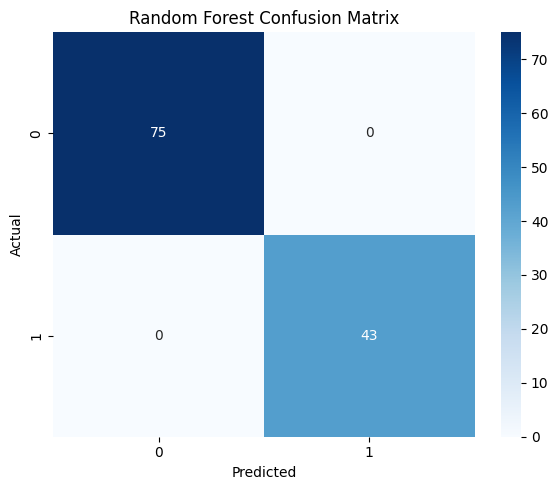

In [172]:

from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

import seaborn as sns

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrix_random_forest.png', bbox_inches='tight')
plt.show()


## 16. Exploratory Analysis: Electric Vehicles by Model Year

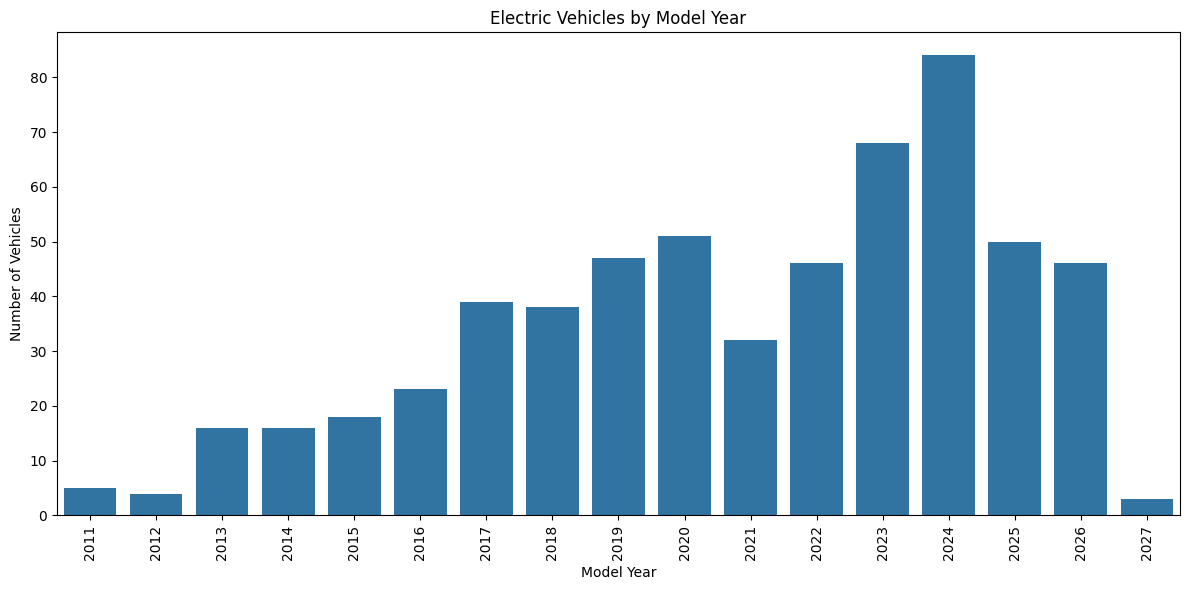

In [173]:
plt.figure(figsize=(12, 6))

sns.countplot(x='model_year', data=df)

plt.xticks(rotation=90)
plt.title('Electric Vehicles by Model Year')
plt.xlabel('Model Year')
plt.ylabel('Number of Vehicles')

plt.tight_layout()
plt.savefig('ev_by_model_year.png', bbox_inches='tight')
plt.show()

## 17. Exploratory Analysis: Electric Range Distribution

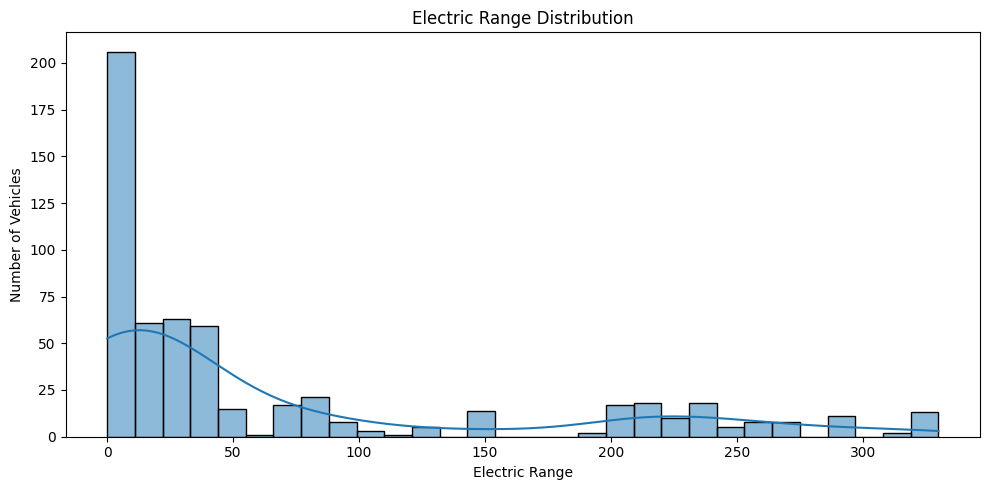

In [174]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df['electric_range'],
    bins=30,
    kde=True
)

plt.title('Electric Range Distribution')
plt.xlabel('Electric Range')
plt.ylabel('Number of Vehicles')

plt.tight_layout()
plt.savefig('electric_range_distribution.png', bbox_inches='tight')
plt.show()

## 18. Exploratory Analysis: Top EV Manufacturers

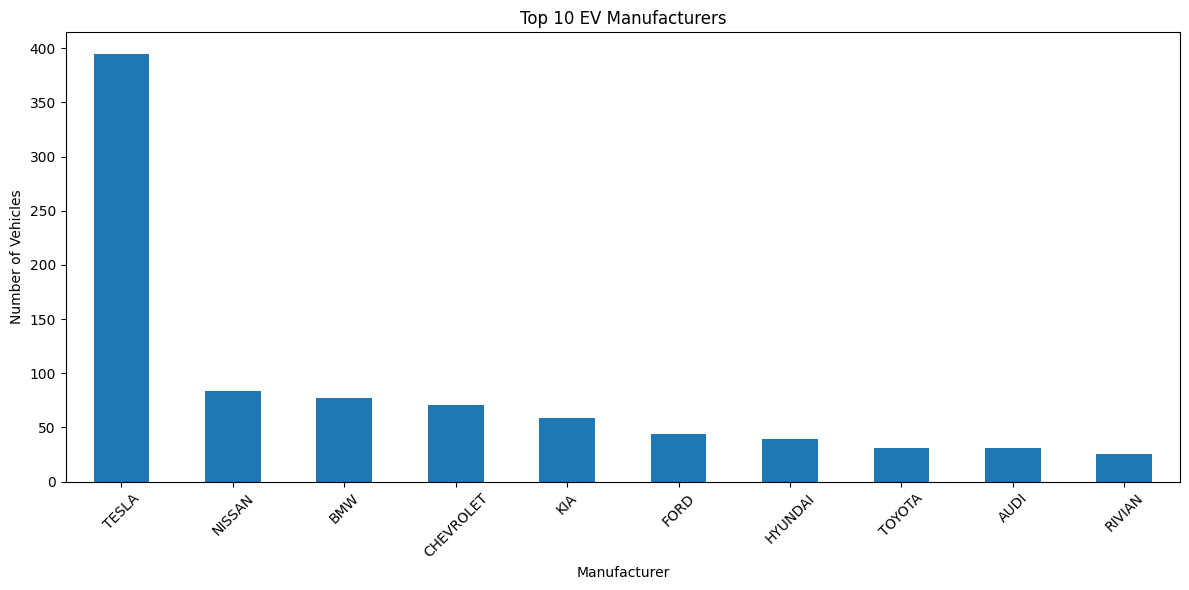

In [175]:
original_df = pd.read_csv(url)

top_brands = original_df['make'].value_counts().head(10)

plt.figure(figsize=(12, 6))

top_brands.plot(kind='bar')

plt.title('Top 10 EV Manufacturers')
plt.xlabel('Manufacturer')
plt.ylabel('Number of Vehicles')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('top_ev_manufacturers.png', bbox_inches='tight')
plt.show()

## 19. Exploratory Analysis: Distribution of Electric Vehicle Types

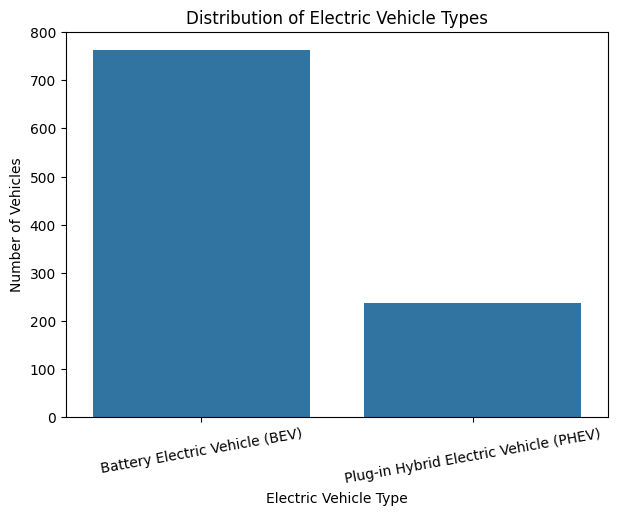

In [139]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x='ev_type',
    data=original_df
)

plt.title('Distribution of Electric Vehicle Types')
plt.xlabel('Electric Vehicle Type')
plt.ylabel('Number of Vehicles')

plt.xticks(rotation=10)

plt.show()

## 20. Feature Importance Analysis

In [140]:
importance = rf_model.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df

,Feature,Importance
3,electric_range,0.503513
2,cafv_type,0.257283
1,make,0.127617
0,model_year,0.099925
4,county,0.011662


## 21. Feature Importance Visualization

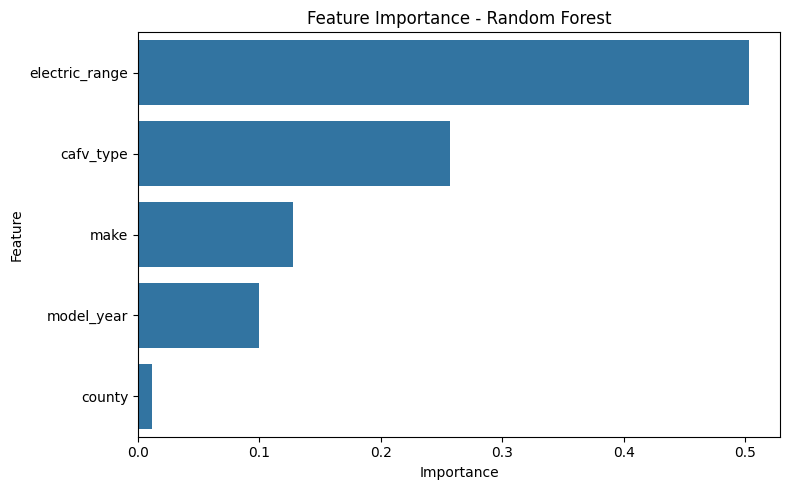

In [170]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df
)

plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.savefig('feature_importance_random_forest.png', bbox_inches='tight')
plt.show()

## 22. Logistic Regression Classification

In [142]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

log_accuracy = accuracy_score(y_test, log_pred)

print("Logistic Regression Accuracy:", log_accuracy)

Logistic Regression Accuracy: 0.635593220338983


## 23. Decision Tree Classification

In [143]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

tree_accuracy = accuracy_score(y_test, tree_pred)

print("Decision Tree Accuracy:", tree_accuracy)

Decision Tree Accuracy: 1.0


## 24. Machine Learning Model Comparison

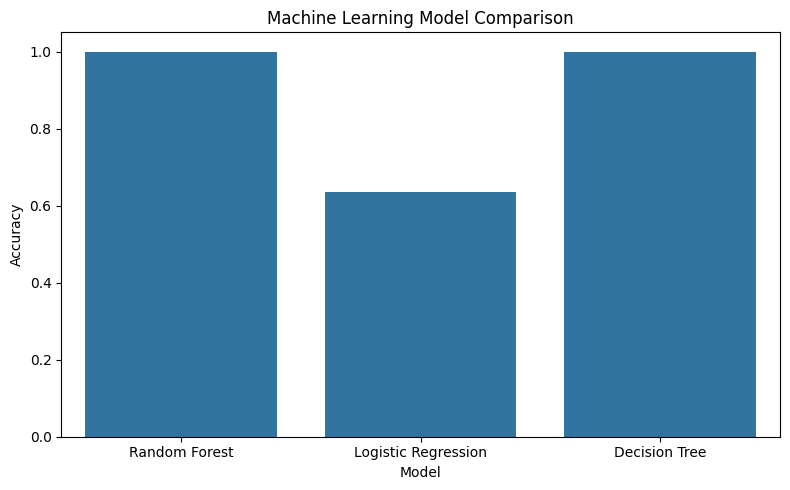

In [177]:
models = [
    'Random Forest',
    'Logistic Regression',
    'Decision Tree'
]

accuracies = [
    rf_accuracy,
    log_accuracy,
    tree_accuracy
]

plt.figure(figsize=(8, 5))

sns.barplot(
    x=models,
    y=accuracies
)

plt.title('Machine Learning Model Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

## 25. Correlation Analysis

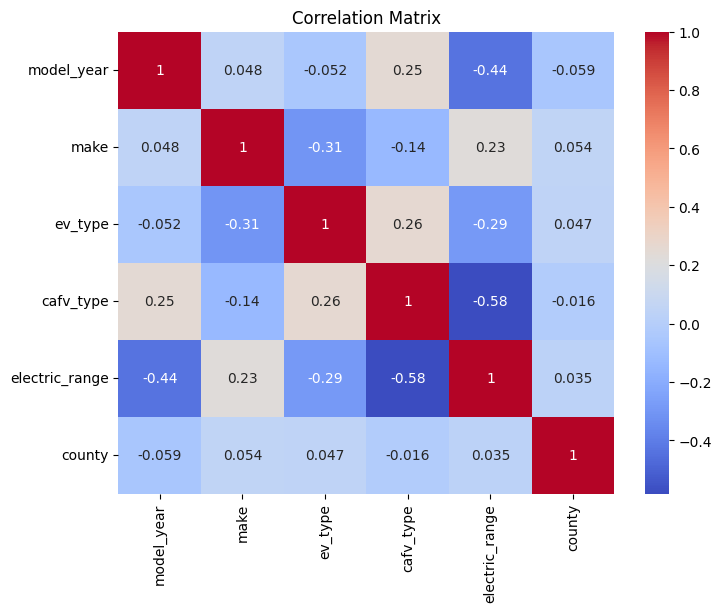

In [145]:
plt.figure(figsize=(8, 6))

corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

## 26. Save the Cleaned Dataset

In [146]:
df.to_csv(
    'cleaned_ev_dataset.csv',
    index=False
)

print("Dataset saved successfully.")

Dataset saved successfully.


## 27. Forecasting Electric Vehicle Growth

The forecasting analysis aggregates the number of electric vehicles by model year and uses the resulting yearly series to forecast future values.

In [147]:
forecast_df = original_df.groupby('model_year').size().reset_index()

forecast_df.columns = ['Year', 'Count']

forecast_df.head()

,Year,Count
0,2011,5
1,2012,4
2,2013,25
3,2014,24
4,2015,28


## 28. Prepare the Data for Forecasting

In [148]:
forecast_df['ds'] = pd.to_datetime(
    forecast_df['Year'],
    format='%Y'
)

forecast_df['y'] = forecast_df['Count']

forecast_df = forecast_df[['ds', 'y']]

forecast_df.head()

,ds,y
0,2011-01-01,5
1,2012-01-01,4
2,2013-01-01,25
3,2014-01-01,24
4,2015-01-01,28


## 29. Train the Prophet Forecasting Model

In [149]:
from prophet import Prophet

model_prophet = Prophet()

model_prophet.fit(forecast_df)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 12.


## 30. Generate Future Dates for the Forecast

In [150]:
future = model_prophet.make_future_dataframe(
    periods=5,
    freq='YE'
)

future.tail()

,ds
17,2027-12-31
18,2028-12-31
19,2029-12-31
20,2030-12-31
21,2031-12-31


## 31. Generate the Forecast

In [151]:
forecast = model_prophet.predict(future)

forecast[['ds', 'yhat']].tail(5)

,ds,yhat
17,2027-12-31,127.377937
18,2028-12-31,121.013788
19,2029-12-31,130.157166
20,2030-12-31,139.281586
21,2031-12-31,148.382355


## 32. Visualize the EV Growth Forecast

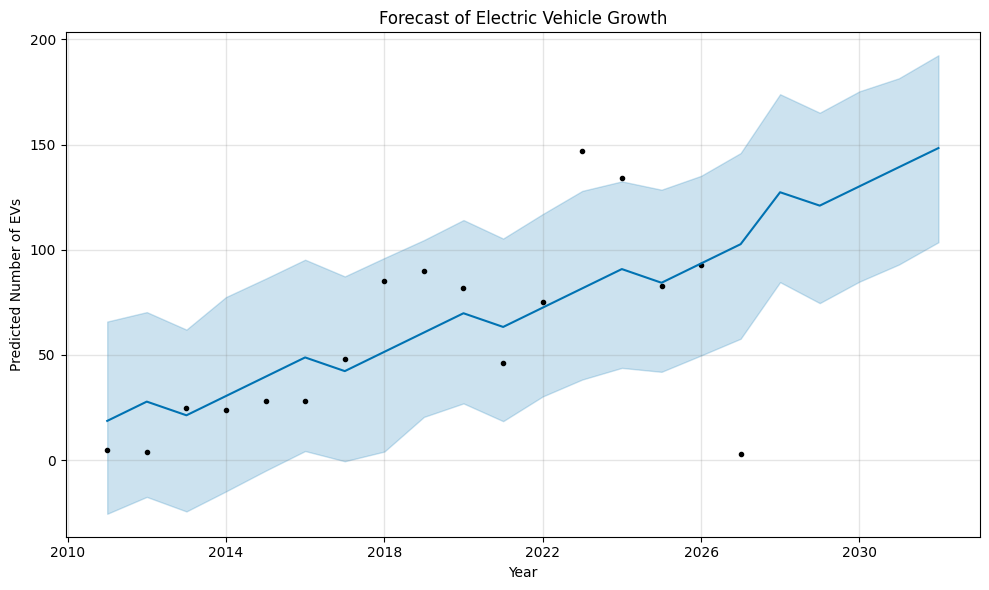

In [178]:
fig = model_prophet.plot(forecast)

plt.title('Forecast of Electric Vehicle Growth')
plt.xlabel('Year')
plt.ylabel('Predicted Number of EVs')

plt.tight_layout()
plt.savefig('ev_growth_forecast.png', bbox_inches='tight')

plt.show()

## 33. Export Forecast Results

In [153]:
forecast_results = forecast[['ds', 'yhat']].tail(5)

forecast_results

,ds,yhat
17,2027-12-31,127.377937
18,2028-12-31,121.013788
19,2029-12-31,130.157166
20,2030-12-31,139.281586
21,2031-12-31,148.382355


In [154]:
forecast_results.to_csv(
    'forecast_results.csv',
    index=False
)

print("Forecast results saved successfully.")

Forecast results saved successfully.


## 34. Actual vs. Forecasted EV Growth

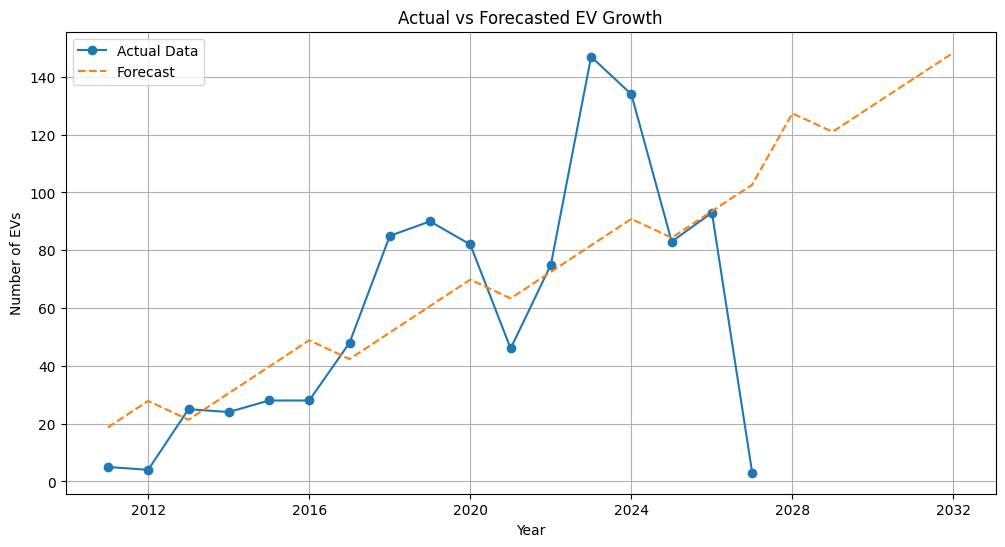

In [155]:
plt.figure(figsize=(12, 6))

# Actual data
plt.plot(
    forecast_df['ds'],
    forecast_df['y'],
    label='Actual Data',
    marker='o'
)

# Forecasted trend
plt.plot(
    forecast['ds'],
    forecast['yhat'],
    label='Forecast',
    linestyle='--'
)

plt.title('Actual vs Forecasted EV Growth')
plt.xlabel('Year')
plt.ylabel('Number of EVs')
plt.legend()
plt.grid(True)

plt.show()

## 35. Conclusion

The analysis combines exploratory data analysis, machine learning classification, feature importance analysis, and time-series forecasting to examine electric vehicle adoption patterns.

The forecasting results provide an estimate of future EV counts based on historical model-year data. These forecasts should be interpreted with caution because they are based on historical trends and do not incorporate external factors such as economic conditions, policy changes, infrastructure development, or consumer behavior.